In [19]:
# Imports

import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

# date = "2026-03-12/"
# slurm_job = 16316301

date = "2026-03-16/"
slurm_job = 16342617
batches = [0, 3, 9, 11, 12, 13, 15, 16, 18]

result_dir = result_dir + date + str(slurm_job) + "/"

runs = [0]

# start at line number 1
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    # If file exists but doesn't have that many lines
    return []

In [20]:
colors = ["red", "darkorange", "gold", "greenyellow", "lime"]
cmap = mcolors.LinearSegmentedColormap.from_list("fitness_map", colors)
norm = mcolors.Normalize(vmin=0.995, vmax=1.0)

# get color
def getColor(fitness):

    return cmap(norm(fitness))
    # if (fitness <= 0.95):
    #     return "red"
    # elif (fitness <= 0.96):
    #     return "darkorange"
    # elif (fitness <= 0.97):
    #     return "gold"
    # elif (fitness <= 0.98):
    #     return "greenyellow"
    # else:
    #     return "lime"

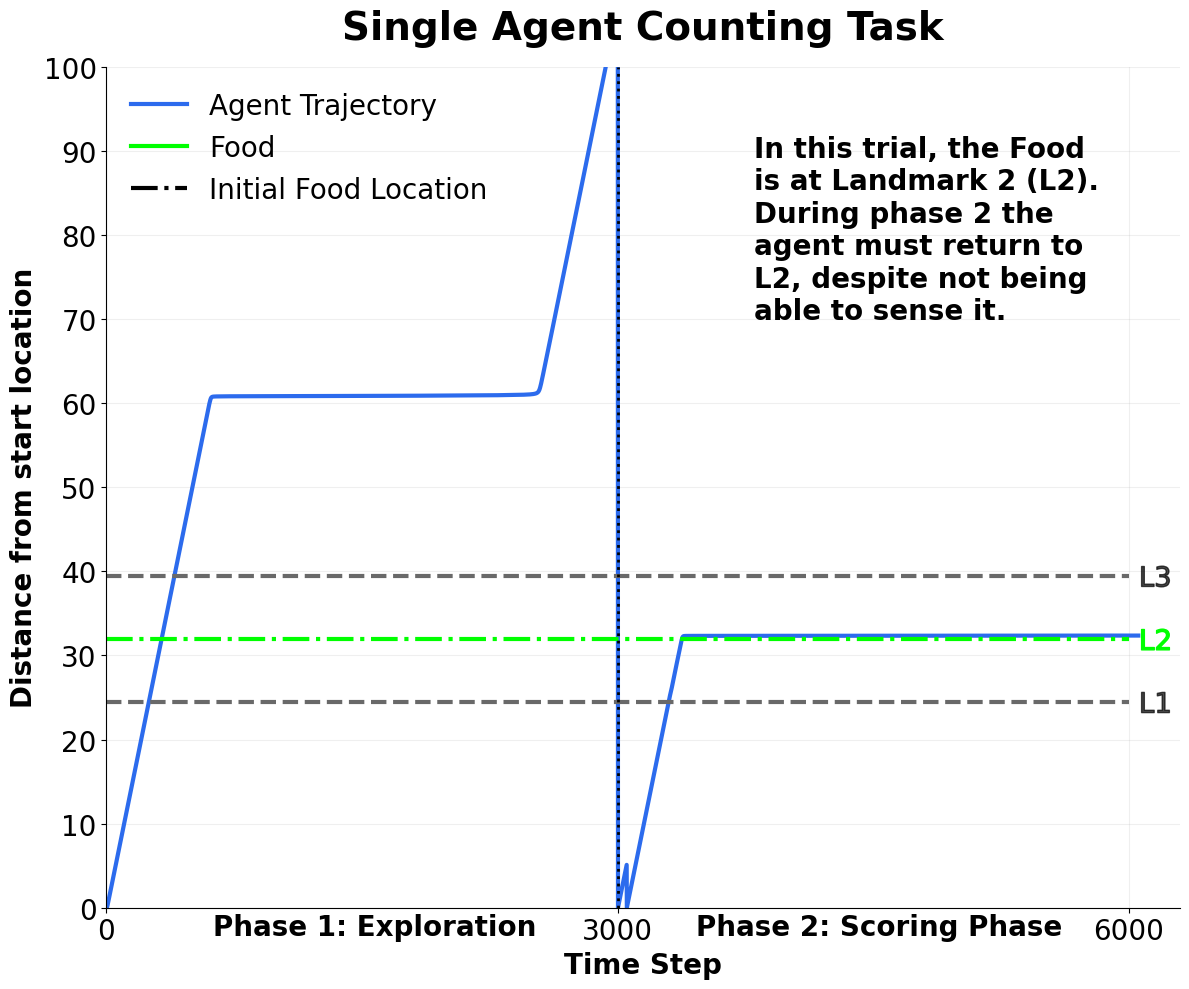

In [59]:
# the plot for a single run, batch and env with only one delay
batch = 18
stage = "stage4"
run = 0
env = 2
counter = 14

fig, ax = plt.subplots(figsize=(12,10))

# file paths
phase1_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{stage}_Phase1.dat"
phase2_dir = result_dir + f"batch_{batch}/run_{run}/behavior_{run}_Env{env}_{stage}_Phase2.dat"
landmark_file = result_dir + f"batch_{batch}/run_{run}/landmark_location_{run}_env{env}_{stage}_phase2.dat"
fitness_file = result_dir + f"batch_{batch}/run_{run}/fitness_{run}_env{env}_{stage}.dat"

# Fitness Colour
fitness = read_ith_line(counter, fitness_file)
color = getColor(fitness[-1])

# Behaviour
behavior = []
phase1 = read_ith_line(1, phase1_dir)
behavior.extend(phase1)
behavior.extend(read_ith_line(counter, phase2_dir))
behaviour_x = list(range(len(behavior)))

ax.plot(behaviour_x, behavior,
        label="Agent Trajectory",
        color="#2C6BED",
        linewidth=3)

# Landmarks
landmark = read_ith_line(counter, landmark_file)

for i in range(3):
    if i == env - 1:
        ax.scatter(len(behaviour_x) + 100, landmark[i],
                   s=400, marker=f"L${i+1}$",
                   zorder=3, color=color)
        ax.hlines(y=landmark[i],
                  xmin=0, xmax=6000,
                  linestyle="-.", linewidth=3,
                  color=color,
                  label="_Food Location")
    else:
        ax.scatter(len(behaviour_x) + 100, landmark[i],
                   s=400, marker=f"L${i+1}$",
                   zorder=2, alpha=0.7, color="black")
        ax.hlines(y=landmark[i],
                  xmin=0, xmax=6000,
                  linestyle="--", linewidth=3,
                  color="dimgrey",
                  label=f"_Landmark {i+1}")

# Phase divider
phase_split = len(phase1)
ax.axvline(phase_split, color="black", linestyle=":", linewidth=2)

# ✅ Phase labels UNDER x-axis
ax.text(0.25, -0.033,
        "Phase 1: Exploration",
        transform=ax.transAxes,
        ha="center",
        fontsize=20,
        fontweight="bold")

ax.text(0.72, -0.033,
        "Phase 2: Scoring Phase",
        transform=ax.transAxes,
        ha="center",
        fontsize=20, 
        fontweight="bold")

# Axes styling
ax.set_ylabel("Distance from start location", fontsize=20, fontweight="bold")
ax.set_xlabel("Time Step", fontsize=20, fontweight="bold")

ax.tick_params(axis='both', labelsize=20)



# Title
ax.set_title("Single Agent Counting Task",
             fontsize=28, pad=20, fontweight="bold")

ax.grid(alpha=0.2)

# Annotation box
ax.text(3800, 70,
        "In this trial, the Food\nis at Landmark 2 (L2).\nDuring phase 2 the\nagent must return to\nL2, despite not being\nable to sense it.",
        fontsize=20, fontweight="bold")

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Axis limits / ticks
ax.set_xlim(0, 6300)
ax.set_ylim(0,100)
ax.set_xticks([0, 3000, 6000])
ax.set_yticks([0, 10,20,30,40,50,60,70,80,90,100])

ax.plot([0], [0], color=getColor(1), label="Food", linewidth=3)
ax.plot([0], [0], color="black", linestyle="-.", label="Initial Food Location", linewidth=3)
# Legend
ax.legend(fontsize=20, frameon=False, loc="upper left")
# ✅ IMPORTANT: prevent clipping of phase labels
plt.tight_layout()

plt.show()